Loading landmark data...
Loaded 212 landmark frames
Loading clip ranges...
Loaded 8 clip segments
Loading contact/separation annotations...
Loaded 8 contact/separation pairs

=== Annotation Validation ===
Clip ranges: 8 entries
CS annotations: 8 entries
✅ Clip 1: Contact 92, Separation 111 (within 79-120)
✅ Clip 2: Contact 137, Separation 155 (within 127-164)
✅ Clip 3: Contact 179, Separation 206 (within 172-215)
✅ Clip 4: Contact 231, Separation 251 (within 223-262)
✅ Clip 5: Contact 282, Separation 303 (within 272-309)
✅ Clip 6: Contact 331, Separation 344 (within 321-353)
✅ Clip 7: Contact 370, Separation 392 (within 363-402)
✅ Clip 8: Contact 417, Separation 442 (within 408-450)

Processing landmarks by clips with z-tangential acceleration...
Clip 1 (79-120): Found 32 landmark frames
Clip 2 (127-164): Found 26 landmark frames
Clip 3 (172-215): Found 32 landmark frames
Clip 4 (223-262): Found 22 landmark frames
Clip 5 (272-309): Found 29 landmark frames
Clip 6 (321-353): Found 23 la

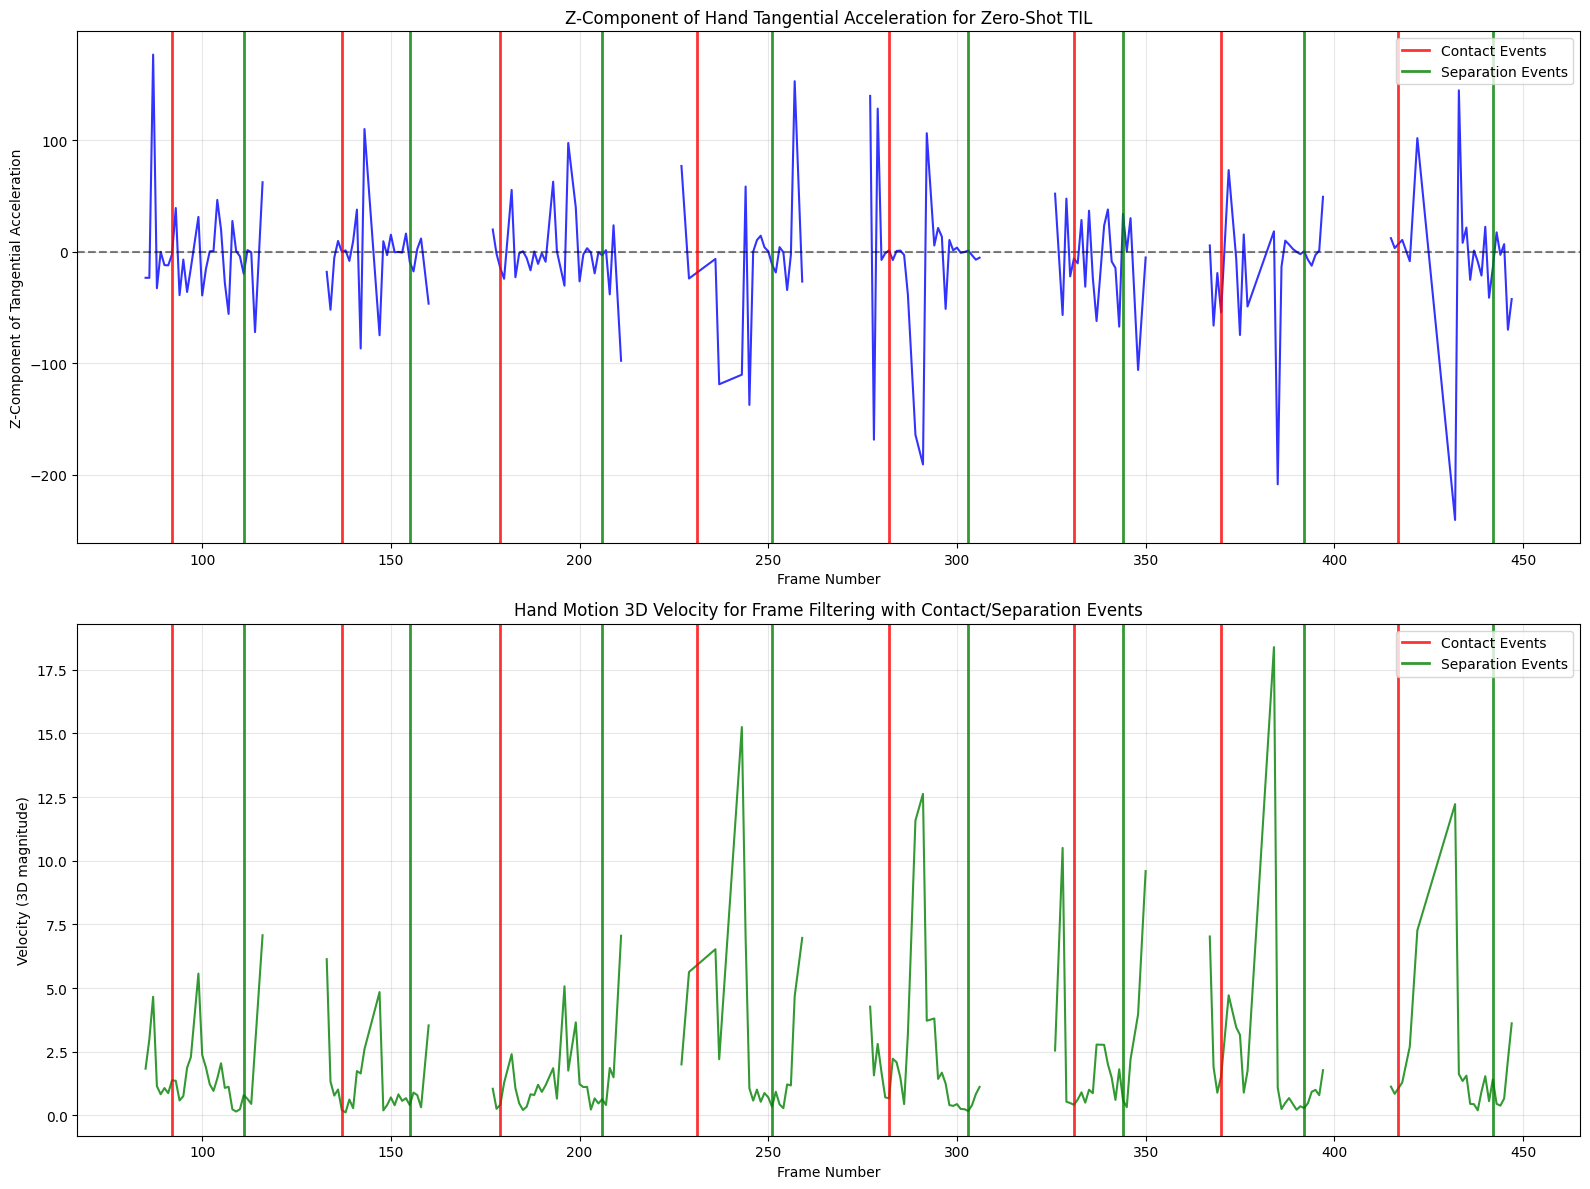

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import re

def parse_landmarks_file(filename):
    """Parse the landmarks file and extract frame numbers and coordinates."""
    landmarks_data = {}
    with open(filename, 'r') as file:
        content = file.read()
    frame_blocks = re.split(r'(\d+):', content)
    for i in range(1, len(frame_blocks), 2):
        frame_num = int(frame_blocks[i])
        landmark_block = frame_blocks[i + 1]
        x_match = re.search(r'x:\s*([-+]?\d*\.?\d+)', landmark_block)
        y_match = re.search(r'y:\s*([-+]?\d*\.?\d+)', landmark_block)
        z_match = re.search(r'z:\s*([-+]?\d*\.?\d+)', landmark_block)
        if x_match and y_match and z_match:
            landmarks_data[frame_num] = {
                'x': float(x_match.group(1)),
                'y': float(y_match.group(1)),
                'z': float(z_match.group(1))
            }
    return landmarks_data

def parse_clip_ranges(filename):
    """Parse clip ranges file with robust error handling."""
    clip_ranges = []
    with open(filename, 'r') as file:
        lines = file.readlines()
    for line_num, line in enumerate(lines, 1):
        line = line.strip()
        if not line:
            continue
        match = re.search(r'\d+\.\s*(\d+),\s*(\d+)', line)
        if match:
            start_frame = int(match.group(1))
            end_frame = int(match.group(2))
            clip_ranges.append((start_frame, end_frame))
        else:
            print(f"Warning: Could not parse line {line_num}: '{line}'")
    return clip_ranges

def parse_cs_annot(filename):
    """Parse contact and separation annotations with robust error handling."""
    cs_annotations = []
    with open(filename, 'r') as file:
        lines = file.readlines()
    for line_num, line in enumerate(lines, 1):
        line = line.strip()
        if not line:
            continue
        match = re.search(r'\d+\.\s*(\d+),\s*(\d+)', line)
        if match:
            contact = int(match.group(1))
            separation = int(match.group(2))
            cs_annotations.append((contact, separation))
        else:
            print(f"Warning: Could not parse line {line_num}: '{line}'")
    return cs_annotations

def validate_annotations(clip_ranges, cs_annotations):
    """Validate that contact/separation frames are within clip boundaries."""
    print(f"\n=== Annotation Validation ===")
    print(f"Clip ranges: {len(clip_ranges)} entries")
    print(f"CS annotations: {len(cs_annotations)} entries")
    if len(clip_ranges) != len(cs_annotations):
        print(f"⚠️  MISMATCH: {len(clip_ranges)} clips vs {len(cs_annotations)} annotations")
        return False
    validation_passed = True
    for i, ((start, end), (contact, separation)) in enumerate(zip(clip_ranges, cs_annotations)):
        clip_num = i + 1
        if not (start <= contact <= end):
            print(f"❌ Clip {clip_num}: Contact frame {contact} outside range ({start}-{end})")
            validation_passed = False
        if not (start <= separation <= end):
            print(f"❌ Clip {clip_num}: Separation frame {separation} outside range ({start}-{end})")
            validation_passed = False
        if contact >= separation:
            print(f"❌ Clip {clip_num}: Contact {contact} should be before separation {separation}")
            validation_passed = False
        if validation_passed:
            print(f"✅ Clip {clip_num}: Contact {contact}, Separation {separation} (within {start}-{end})")
    return validation_passed

def calculate_hand_tangential_acceleration_z_component(landmarks, fps=30):
    """
    For each frame, computes the z-component of the tangential acceleration vector,
    i.e., the portion of the tangential acceleration along the z-axis.
    """
    if len(landmarks) < 3:
        return [], []
    positions = np.array([[lm['x'], lm['y'], lm['z']] for lm in landmarks])
    dt = 1.0 / fps
    velocities = np.diff(positions, axis=0) / dt
    accelerations = np.diff(velocities, axis=0) / dt
    tangential_accel_z = []
    velocity_magnitudes = np.linalg.norm(velocities[1:], axis=1)
    for i in range(len(accelerations)):
        v = velocities[i + 1]
        a = accelerations[i]
        v_norm = np.linalg.norm(v)
        if v_norm > 1e-10:
            v_hat = v / v_norm
            a_tang = np.dot(a, v_hat) * v_hat      # Full tangential acceleration vector
            tangential_accel_z.append(a_tang[2])   # Take z-component
        else:
            tangential_accel_z.append(0.0)
    return tangential_accel_z, velocity_magnitudes.tolist()

def process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30):
    """Process landmarks by clips, returning data organized by clips."""
    clip_data = []
    for clip_idx, (start_frame, end_frame) in enumerate(clip_ranges):
        clip_frames = []
        clip_landmarks = []
        for frame_num in sorted(landmarks_data.keys()):
            if start_frame <= frame_num <= end_frame:
                clip_frames.append(frame_num)
                clip_landmarks.append(landmarks_data[frame_num])
        print(f"Clip {clip_idx + 1} ({start_frame}-{end_frame}): Found {len(clip_landmarks)} landmark frames")
        if len(clip_landmarks) >= 3:
            # Use z-component of tangential acceleration
            accelerations, velocities = calculate_hand_tangential_acceleration_z_component(clip_landmarks, fps)
            accel_frames = clip_frames[2:]  # aligned with acceleration
            clip_data.append({
                'frames': accel_frames,
                'velocities': velocities,
                'accelerations': accelerations,
                'clip_range': (start_frame, end_frame),
                'clip_index': clip_idx
            })
        else:
            print(f"⚠️  Clip {clip_idx + 1}: Not enough landmarks for motion analysis")
    return clip_data

def create_disjoint_motion_plots_with_annotations(clip_data, cs_annotations):
    """Plot z-component of tangential acceleration (top), velocity magnitude (bottom), with annotations."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
    # Plot z-tangential acceleration
    all_accelerations = []
    for clip in clip_data:
        ax1.plot(clip['frames'], clip['accelerations'], 'b-', linewidth=1.5, alpha=0.8)
        all_accelerations.extend(clip['accelerations'])
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Z-Component of Tangential Acceleration')
    ax1.set_title('Z-Component of Hand Tangential Acceleration for Zero-Shot TIL')
    ax1.grid(True, alpha=0.3)
    contact_label_added = False
    separation_label_added = False
    annotation_count = min(len(clip_data), len(cs_annotations))
    for i in range(annotation_count):
        contact, separation = cs_annotations[i]
        if not contact_label_added:
            ax1.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2, label='Contact Events')
            contact_label_added = True
        else:
            ax1.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2)
        if not separation_label_added:
            ax1.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2, label='Separation Events')
            separation_label_added = True
        else:
            ax1.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2)
    ax1.legend(loc='upper right')

    # Plot velocity (3D magnitude)
    all_velocities = []
    for clip in clip_data:
        ax2.plot(clip['frames'], clip['velocities'], 'g-', linewidth=1.5, alpha=0.8)
        all_velocities.extend(clip['velocities'])
    ax2.set_xlabel('Frame Number')
    ax2.set_ylabel('Velocity (3D magnitude)')
    ax2.set_title('Hand Motion 3D Velocity for Frame Filtering with Contact/Separation Events')
    ax2.grid(True, alpha=0.3)
    contact_label_added = False
    separation_label_added = False
    for i in range(annotation_count):
        contact, separation = cs_annotations[i]
        if not contact_label_added:
            ax2.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2, label='Contact Events')
            contact_label_added = True
        else:
            ax2.axvline(x=contact, color='red', linestyle='-', alpha=0.8, linewidth=2)
        if not separation_label_added:
            ax2.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2, label='Separation Events')
            separation_label_added = True
        else:
            ax2.axvline(x=separation, color='green', linestyle='-', alpha=0.8, linewidth=2)
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    return fig

def main():
    """Main function for z-tangential acceleration analysis in zero-shot TIL."""
    landmarks_file = "../test_data/5th_landmarks_trimmed.txt"
    clip_ranges_file = "../test_data/clip_ranges_10.txt"
    cs_annot_file = "../test_data/cs_annot.txt"
    print("Loading landmark data...")
    landmarks_data = parse_landmarks_file(landmarks_file)
    print(f"Loaded {len(landmarks_data)} landmark frames")
    print("Loading clip ranges...")
    clip_ranges = parse_clip_ranges(clip_ranges_file)
    print(f"Loaded {len(clip_ranges)} clip segments")
    print("Loading contact/separation annotations...")
    cs_annotations = parse_cs_annot(cs_annot_file)
    print(f"Loaded {len(cs_annotations)} contact/separation pairs")
    validation_passed = validate_annotations(clip_ranges, cs_annotations)
    if not validation_passed:
        print("⚠️  Validation failed, but continuing with analysis...")
    print("\nProcessing landmarks by clips with z-tangential acceleration...")
    clip_data = process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30)
    print(f"\n=== Z Tangential Acceleration Motion Analysis Results ===")
    for i, clip in enumerate(clip_data):
        print(f"Clip {i+1} ({clip['clip_range'][0]}-{clip['clip_range'][1]}): "
              f"{len(clip['frames'])} frames with motion data")
    print("\n=== Creating Z-Tangential Acceleration Plots for Zero-Shot TIL Research ===")
    create_disjoint_motion_plots_with_annotations(clip_data, cs_annotations)
    # Optionally add filtering/statistics logic here

if __name__ == "__main__":
    main()
